In [1]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import statsmodels.api as sm
import statsmodels.formula.api as smf


# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings
from utils.preprocess_listings import desc_catORnum
from utils import modeling_did


# 标准版存档V0：

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}

tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
]
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

In [2]:
# path_df="../data_processed\listings_tactics_bio_vis-paris_london-2306_2406_ols.csv"
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
df_all=pd.read_csv(path_df)
print(df_all.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\571702545.py:3: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv(path_df)


(266852, 125)


In [3]:
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")

print(df_all[tactics_bio].isna().value_counts())
print(df_all["host_picture_type"].isna().value_counts())

df_all['time']=df_all['time'].astype(str)
print(df_all.time.dtype)

ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64
host_picture_type
False    266852
Name: count, dtype: int64
object


In [5]:
# df_all["time"]=df_all["time"].astype(str)
# df_all['trend'] = df_all['time'].map({'2306':0, "2312":1, '2406':2})#***
print(df_all[['in_paris',"time","trend","post"]].value_counts(dropna=False))
# print(df_all['time'].dtype)
# df_all['time']=df_all['time'].astype(str)

in_paris  time  trend  post
1         2406  2      1       62738
0         2406  2      1       49856
          2312  1      0       43172
          2306  0      0       42356
1         2312  1      0       35829
          2306  0      0       32901
Name: count, dtype: int64


In [5]:
# df_all.to_csv(path_df, index=False)

## pre trend check

In [5]:
df_pre=df_all[df_all['time']!="2406"]
print(df_pre.shape)
print(df_pre[['time','in_paris']].value_counts())

(266852, 125)
time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64


In [147]:
## pre trend check!!!

# booking_rate_l90d
df=df_pre.copy()
formula= (" booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating + number_of_reviews_ltm +"
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate + C(host_response_time)+ "
            "has_text + lang_fr + lang_en + text_length +"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "in_paris * C(time)"
)
model=smf.ols(formula, data=df).fit(cov_type="HC1")#robust standard errors
summary=model.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.398
Method:                 Least Squares   F-statistic:                     2802.
Date:                Tue, 07 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:54:56   Log-Likelihood:                 88109.
No. Observations:              266852   AIC:                        -1.762e+05
Df Residuals:                  266824   BIC:                        -1.759e+05
Df Model:                          27                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------


## + trend: "C(time) + in_paris*trend + in_paris * post"


In [ ]:

# ✔ 1. C(time) # 控制所有城市共同的时间变化（宏观趋势）
# ✔ 2. in_paris * trend # 允许 Paris 和 London 有不同的趋势（解决你发现的不平行问题）
# ✔ 3. in_paris * post # 👉 在控制趋势差异之后，识别 JO 的“额外冲击”

# 在控制了城市固定差异、时间效应以及城市特定趋势（city-specific trends）之后，
# in_paris × post 捕捉了 2024年巴黎奥运会 对 Paris 相对于 London 的“额外变化”（differential change）

# 优点： 清晰、好解释（有一个系数）
# 缺点： 强结构假设的 DiD（parametric DiD）：
# pre-trend 是线性的
# treatment effect 是“一个跳跃 + 一个趋势修正”


In [10]:
def run_tactic_model_by_trend(df, y):
    formula= (f"{y} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris*trend + in_paris * post"
    )
              
            # "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
            # "C(host_picture_type) +"
            # "pic_no_person + pic_pro_style + pic_life_style +"
            # " is_smiling + "
            # "C(age_class) + C(gender) +"
            
    model_tactic=smf.ols(formula, data=df).fit()
    # summary=model_tactic.summary()
    # print(summary)
    return model_tactic

df=df_all.copy()

results=[]
for var in tactics_bio:
    print(var)
    model=run_tactic_model_by_trend(df, var)
    term="in_paris:post"
    coef = model.params[term]
    se = model.bse[term]
    pval = model.pvalues[term]
    
    results.append({
        "variable": var,
        "coef": coef,
        "se": se,
        "pval": pval,
        "sig": p_to_sig(pval),
        "ci_low": coef - 1.96 * se,
        "ci_high": coef + 1.96 * se
    })
results_df = pd.DataFrame(results)


ouverture
authenticité
sociabilité
auto_promotion
exemplarité


In [11]:
results_df

,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.009624,0.010803,0.373031,,-0.030798,0.011551
1,authenticité,-0.015611,0.011191,0.163017,,-0.037545,0.006323
2,sociabilité,-0.009865,0.011565,0.393671,,-0.032532,0.012803
3,auto_promotion,0.042751,0.010544,0.000050,***,0.022086,0.063417
4,exemplarité,0.044509,0.011202,0.000071,***,0.022553,0.066464


<Figure size 640x480 with 0 Axes>

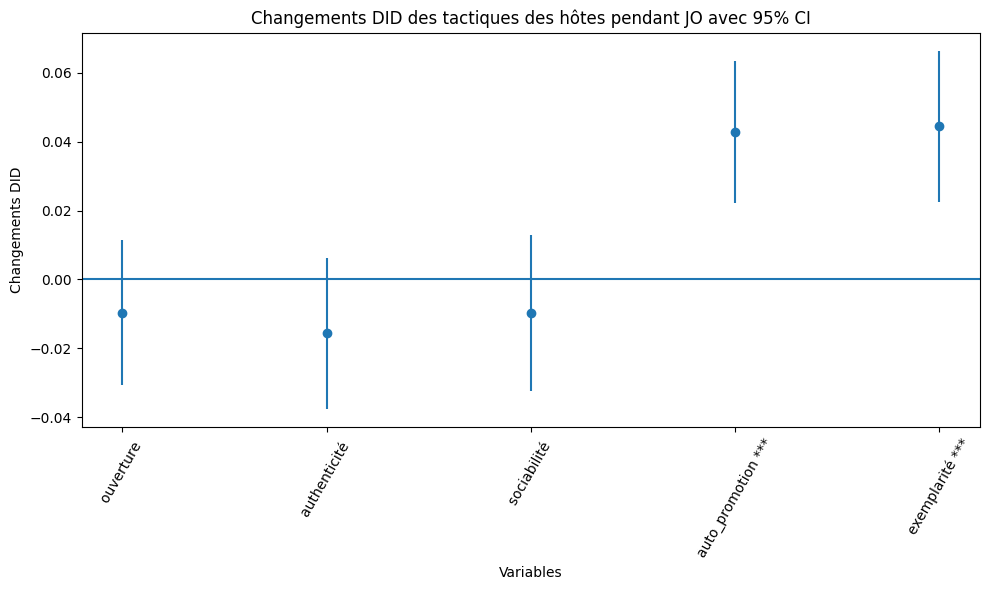

In [46]:
# did effect
import pandas as pd
import matplotlib.pyplot as plt

results_df['label']=results_df['variable']+" "+results_df['sig']

plt.figure()
plt.figure(figsize=(10,6))
plt.errorbar(
    results_df["label"],
    results_df["coef"],
    yerr=[results_df["coef"] - results_df["ci_low"],
          results_df["ci_high"] - results_df["coef"]],
    fmt='o', 
)
plt.axhline(0)  # 0线（是否显著）
plt.xlabel("Variables")
plt.ylabel("Changements DID")
plt.title("Changements DID des tactiques des hôtes pendant JO avec 95% CI")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

## event study :C(time) + in_paris * C(time)


In [ ]:
## event study :C(time) + in_paris * C(time)
# 不假设差异趋势是线性的
# # 弱假设 / 非参数 DiD（event study）：[更加稳健]
# 每个时间点可以自由变化,不强制趋势形状
##==允许：2312 下跌，2406 反弹，不规则变化

# C(time)固定时间变化（季节，整体增长）
# 交互项：paris(相对于london)[在每个时间点]的额外变化

# | 时间   | Paris 相对 London 的差异 |
# | ---- | ------------------- |
# | 2306 | baseline（被省略）     |
# | 2312 | β₁（pre-trend）       |
# | 2406 | β₂（JO + trend）      |
# JO effect ≈ β_2406 - β_2312 (24差异减去稳定差异==jo额外差异)

# 线性组合计算β_2406 - β_2312 = 0 ?


##结果差异，不仅因为数据不稳定，还有模型假设的差异

In [19]:
importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time

df=df_all.copy()
var="auto_promotion"
model_tactic=run_tactic_model_by_time(df, y=var)
print(model_tactic.summary())

                            OLS Regression Results                            
Dep. Variable:         auto_promotion   R-squared:                       0.267
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     3604.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        09:36:25   Log-Likelihood:            -2.4809e+05
No. Observations:              266852   AIC:                         4.962e+05
Df Residuals:                  266824   BIC:                         4.965e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [20]:

## XXXXX真实效应组成:
#这里观察的是y的变化！

# london 2306: baseline
# london 2312 :  C(time)[T.2312]
# london 2406 :  C(time)[T.2406]

# paris 2306: in_paris
# paris 2312 :  in_paris:C(time)[T.2312]
# paris 2406 :  in_paris:C(time)[T.2406]

### ???
# delta 2306: in_paris
# delta 2312 : in_paris:C(time)[T.2312]- C(time)[T.2312]
# delta 2406 : in_paris:C(time)[T.2406]- C(time)[T.2406]


In [21]:
# event study 图：Paris 相对于 London，在不同时间点的“动态差异路径”
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect

# var="auto_promotion"
model=model_tactic
data=get_event_study_data(model, var=var)
display(data)

ddd=get_ddd_effect(model, var=var)
display(ddd)

,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN,NaN,,2306
1,2312,-0.014188,-0.026529,-0.001847,auto_promotion,0.006296,0.024241,*,2312 *
2,2406,0.014376,0.002894,0.025857,auto_promotion,0.005858,0.014128,*,2406 *


auto_promotion


,variable,coef,se,pval,sig,ci_low,ci_high
0,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839


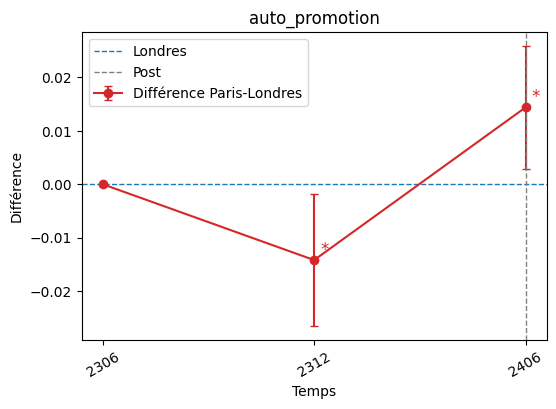

In [22]:
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one_did

plot_one_did(data,axes=None, var='auto_promotion')

# 大于零，策略相对于london增加，小于0，策略减少

In [13]:
df=df_all.copy()
data_list=[]
for i, y in enumerate(tactics_bio):
    # if i >1:
    #     break  
    print (i, y)
    model=run_tactic_model_by_time(df, y)
    data = get_event_study_data(model, var=y)
    data_list.append(data)
data_all=pd.concat(data_list, axis=0)
data_all

0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,ouverture,NaN,NaN,,2306
1,2312,0.005668,-0.006977,0.018313,ouverture,0.006452,3.796275e-01,,2312
2,2406,0.001713,-0.010052,0.013477,ouverture,0.006002,7.753645e-01,,2406
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,,2306
1,2312,0.029654,0.016556,0.042753,authenticité,0.006683,9.113254e-06,***,2312 ***
2,2406,0.043697,0.031511,0.055884,authenticité,0.006218,2.099537e-12,***,2406 ***
0,2306,0.000000,0.000000,0.000000,sociabilité,NaN,NaN,,2306
1,2312,0.022324,0.008787,0.035861,sociabilité,0.006906,1.228010e-03,**,2312 **
2,2406,0.034783,0.022189,0.047377,sociabilité,0.006426,6.193342e-08,***,2406 ***
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN,NaN,,2306


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\1858148240.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


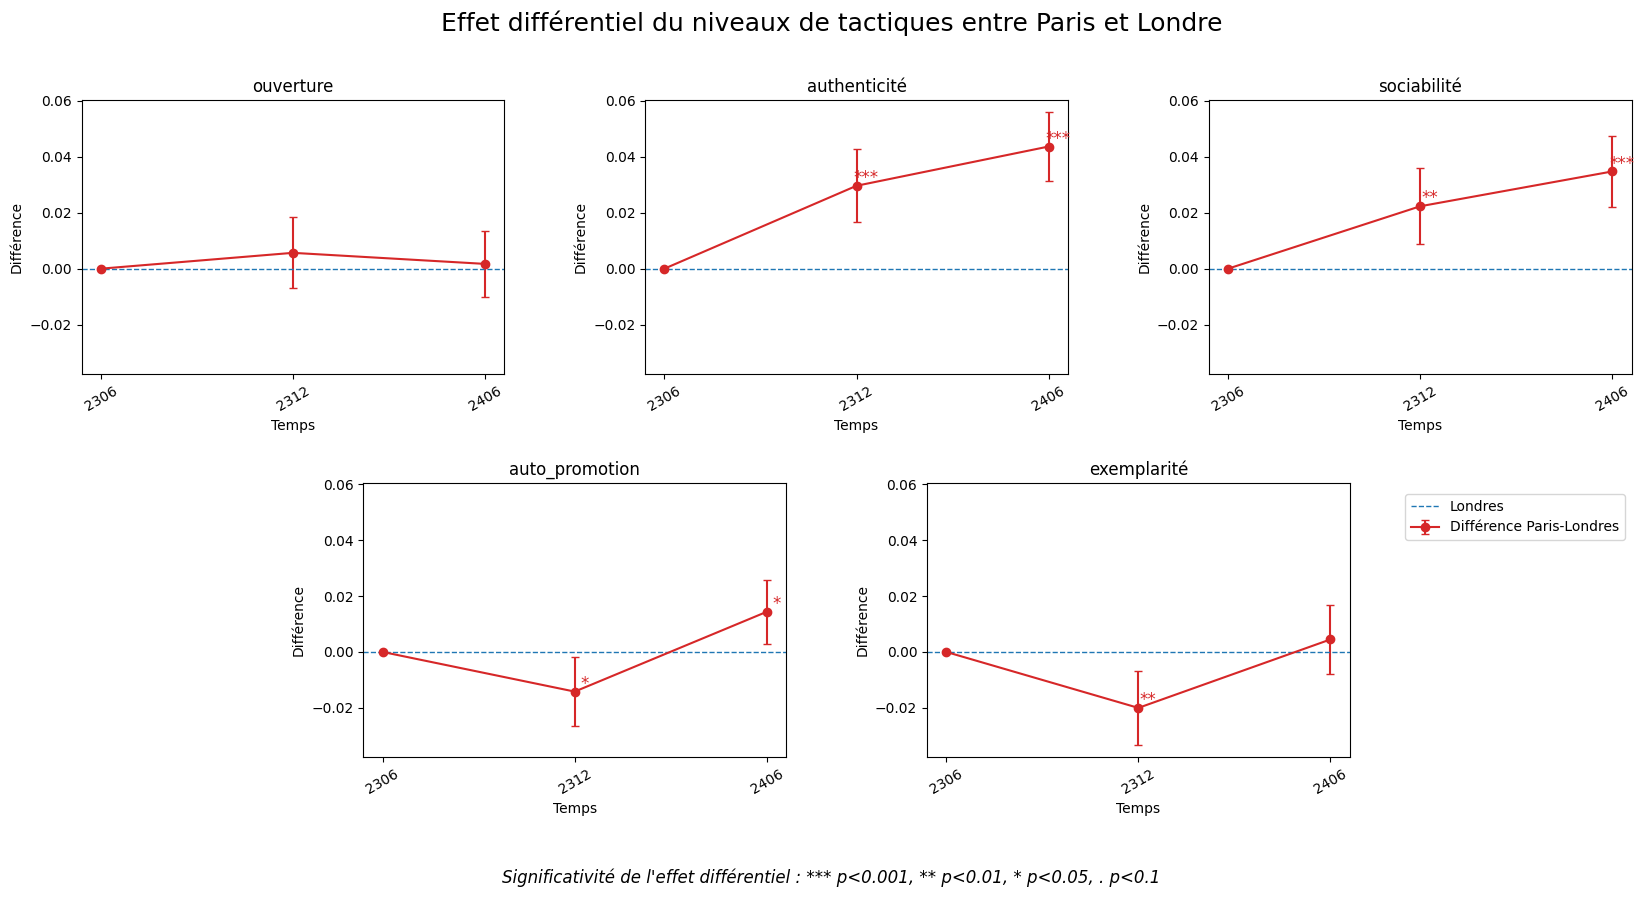

In [167]:
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one_did
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec

## plot
# --------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4],sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6],sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3],sharey=ax1)
ax5 = fig.add_subplot(gs[1, 3:5],sharey=ax1)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


for i, var in enumerate(tactics_bio):
    plot_one_did(data=data_all, axes=axes, i=i, var=var)
fig.suptitle(
        "Effet différentiel du niveaux de tactiques entre Paris et Londre",
        fontsize=18,
        y=0.98
    )


# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet différentiel : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# --------------------------------------------
# 在event study，不对趋势形状做任何假设，如果不存在jo，我们认为2406的差异和2312一样，两个点处于一条水平线上
# 所以jo的效应偏离这条差异水平线
# 如果trend是线性的，2406没有jo的差异会落在延长线上，表示两地的差异不断扩大

# ------------------------MECANISME--------------------------
# 每个点是交互项的coef代表除去in_paris, C(time)之外的其他变化, in_paris:2312, in_paris:2406
# 变化的差值，[变化水平]差值！
# ***假设paris和london的从同一基线（2306）出发，paris 比london多变化或少变化多少

# (Paris_t - Paris_2306)
# -
# (London_t - London_2306)
# =
# (Paris_t -London_t) -(Paris_2306-London_2306)
# 一个时间点的水平变化差-水平基准差(2306)=这个时间点真正的水平差值


# *** La différence en différences des niveau de tactique entre Paris et Londres, au delà de leur différence de base
# si la tactique n'est pas affecté par un choc extérieur, la tendance doit rester horizontal!
# si la ligne descend de dec 2023 au juin 2024, cad la différence diminue; au contraire différence s'élargit davantage
## comme la différence existent avant jo, l'effet réel est la distance verticale entre 2312 et 2406


## 【解释有变化！！！因果关系！变化大小？】
## 仅变化是否（因受到冲击）显著改变，变化是否扩大还是缩小（红线上升或者下降）# 点代表change，折线代表change in change
# 如果没有冲击2406和2312应该平行
# 不代表实际水平的变化方向（不需要用一张图解释所有）








# ------------------------RESULTS--------------------------
# ***
# 不是单纯的一个时间点上两个城市之间的差值！！！！而是差值的差值！（减去了及基准组的差值）
# au dela de la différence initiale, on mesure la différence entre les deux, qui peut être dû aux chocs extérieurs: la saisonnalité, l'événement spécial...  
# 把2312当作基准，检查是否有pre-trend, 2406和2312之间的垂直距离ddd表示了（JO）的对于水平的提升/减少效果
# ***
# 1) 看变化的方向：扩大还是减小
# 2) 看ddd

# 在2406：
## ouv原本的变化减少，auth，socio，auto，exem增多
### 不代表！真实水平的趋势

### predict line+ counterfactual line

In [323]:
df=df_all.copy()
y='authenticité'
model=run_tactic_model_by_time(df, y)


In [324]:
ddd=get_ddd_effect(model, var=y)
display(ddd)

authenticité


,variable,coef,se,pval,sig,ci_low,ci_high
0,authenticité,0.014043,0.006106,0.021454,*,0.002076,0.026011


ddd of authenticité: 0.014043224391017566


,in_paris,time,y_hat,y_cf,variable
0,0,2306,-0.181066,-0.181066,authenticité
1,0,2312,-0.204839,-0.204839,authenticité
2,0,2406,-0.216109,-0.216109,authenticité
3,1,2306,-0.158274,-0.158274,authenticité
4,1,2312,-0.155755,-0.155755,authenticité
5,1,2406,-0.144402,-0.158445,authenticité


axis x : [0, 1, 2]


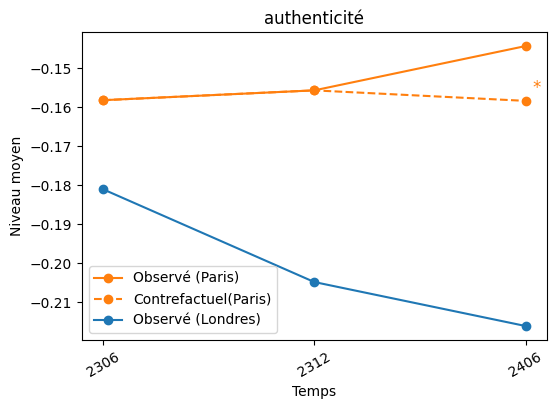

In [334]:
importlib.reload(modeling_did)
from utils.modeling_did import get_cf_data, plot_one_cf

var="authenticité"
agg=get_cf_data(df, model, var=var)
ddd_sig=ddd[ddd['variable']==var]['sig'].iloc[0]
plot_one_cf(agg, axes=None, i=0, var=var, ddd_sig=ddd_sig)


In [190]:
importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time,get_cf_data, plot_one_cf

agg_list=[]
ddd_list=[]

for i, y in enumerate(tactics_bio):
    # print(i, y)
    df=df_all.copy()
    model=run_tactic_model_by_time(df, y)
    ddd=get_ddd_effect(model, var=y)
    agg=get_cf_data(df, model, var=y)
    ddd_list.append(ddd)
    agg_list.append(agg)
    # plot_one_cf(agg, axes=None, i=0, var=y)
df_ddd=pd.concat(ddd_list, axis=0)
df_agg=pd.concat(agg_list, axis=0)


ouverture
ddd of ouverture: -0.003955410205441894
authenticité
ddd of authenticité: 0.014043224391017566
sociabilité
ddd of sociabilité: 0.012459292106811095
auto_promotion
ddd of auto_promotion: 0.028563511199381705
exemplarité
ddd of exemplarité: 0.024491717931886266


In [191]:
display(df_agg)
display(df_ddd)


,in_paris,time,y_hat,y_cf,variable
0,0,2306,-0.111349,-0.111349,ouverture
1,0,2312,-0.111726,-0.111726,ouverture
2,0,2406,-0.113564,-0.113564,ouverture
3,1,2306,-0.093083,-0.093083,ouverture
4,1,2312,-0.083193,-0.083193,ouverture
5,1,2406,-0.088205,-0.084249,ouverture
0,0,2306,-0.181066,-0.181066,authenticité
1,0,2312,-0.204839,-0.204839,authenticité
2,0,2406,-0.216109,-0.216109,authenticité
3,1,2306,-0.158274,-0.158274,authenticité


,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.003955,0.005895,5.022069e-01,,-0.015509,0.007598
0,authenticité,0.014043,0.006106,2.145399e-02,*,0.002076,0.026011
0,sociabilité,0.012459,0.006310,4.832976e-02,*,0.000091,0.024827
0,auto_promotion,0.028564,0.005753,6.870991e-07,***,0.017288,0.039839
0,exemplarité,0.024492,0.006112,6.149051e-05,***,0.012512,0.036471


ouverture
axis x : [0, 1, 2]
authenticité
axis x : [0, 1, 2]
sociabilité
axis x : [0, 1, 2]
auto_promotion
axis x : [0, 1, 2]
exemplarité
axis x : [0, 1, 2]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\1123296355.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


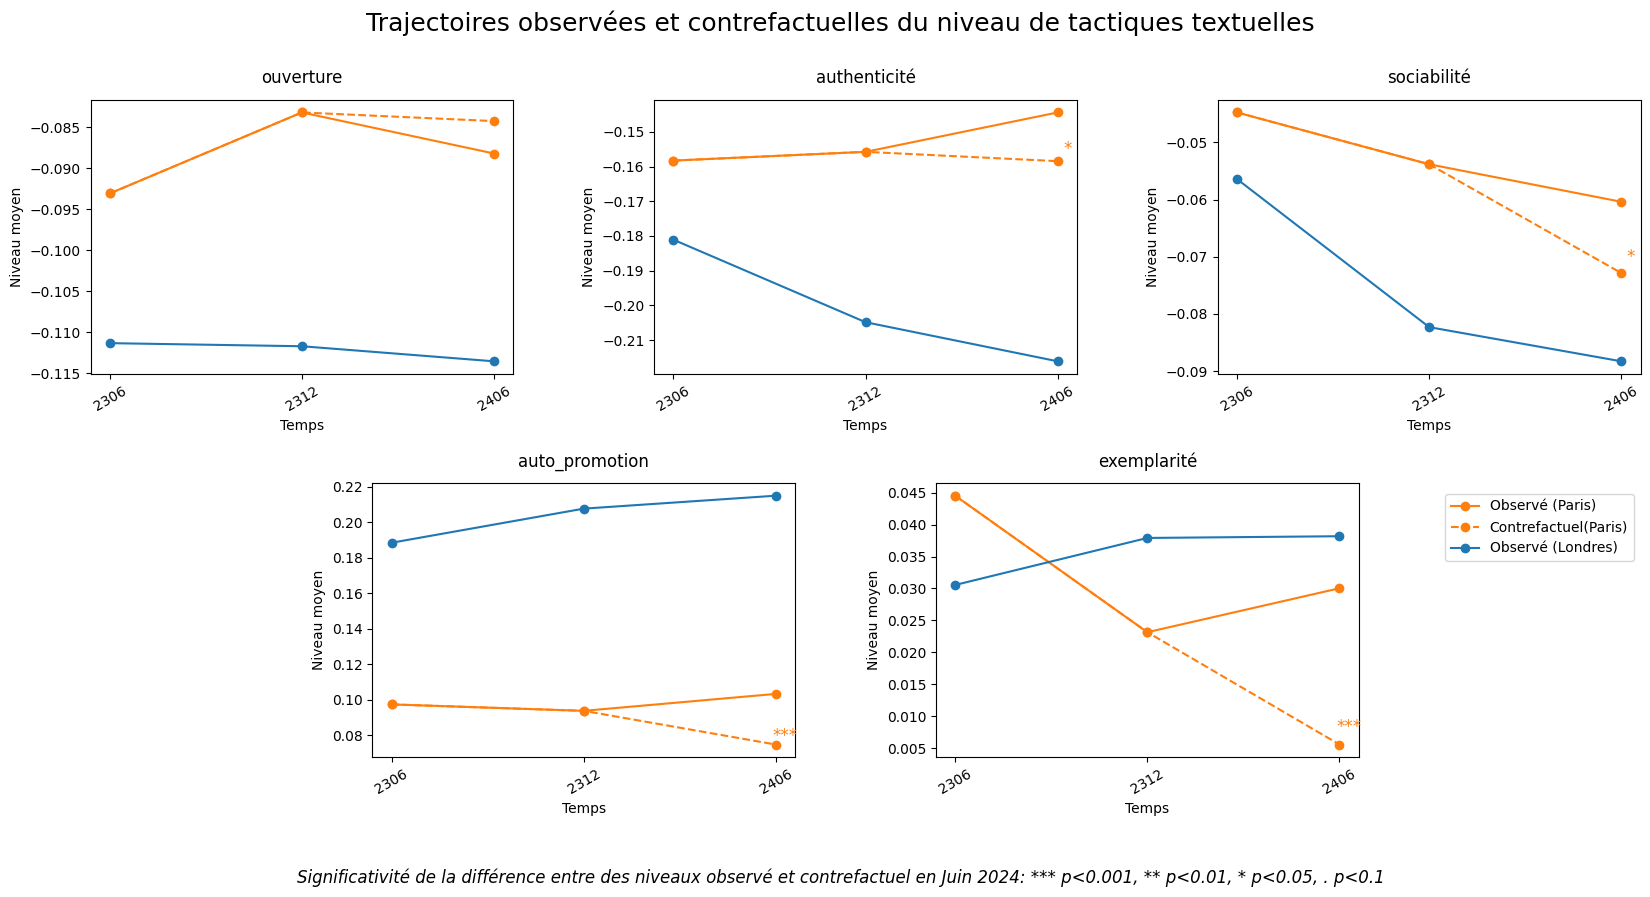

In [192]:

importlib.reload(modeling_did)
from utils.modeling_did import run_tactic_model_by_time,get_cf_data, plot_one_cf

# ---layout---
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


## plot:
for i, var in enumerate(tactics_bio):
    print(var)
    agg=df_agg[df_agg['variable']==var]
    ddd_sig=df_ddd[df_ddd['variable']==var]['sig'].loc[0]
    plot_one_cf(agg, axes=axes, i=i,  var=var, ddd_sig=ddd_sig)


# layout:
fig.suptitle(
        "Trajectoires observées et contrefactuelles du niveau de tactiques textuelles",
        fontsize=18,
        y=0.98
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence entre des niveaux observé et contrefactuel en Juin 2024: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()
# --------------------------------------------

# ------------------------RESULTS--------------------------
# 每一个时间点的垂直距离-2306垂直距离=红线差异线的高度（额外差异）


## 【观察实际怎么变化】
# ouv+soc下降，auth+auto+exem上升
## ==> 分新老房东的贡献！

# 橙色虚线和实现之间的垂直距离，代表ddd（JO）对于策略平均水平的影响的大小，*代表影响的显著性
# 虚线在上说明jo由削弱作用，实线在上说明由提升作用：
# 整体上，jo对几乎所有策略都有提升作用！


## cat var

In [182]:
# porportion变化

df=df_all.copy()
df['is_portrait']=df["host_picture_type"].apply(lambda x : 1 if x=="pro_style" else 0)
print(df['is_portrait'].value_counts(dropna=False))

df['is_lifestyle']=df["host_picture_type"].apply(lambda x : 1 if x=="life_style" else 0)
print(df['is_lifestyle'].value_counts(dropna=False))

df['no_person']=df["host_picture_type"].apply(lambda x : 1 if x=="no_person" else 0)
print(df['no_person'].value_counts(dropna=False))


is_portrait
0    172204
1     94648
Name: count, dtype: int64
is_lifestyle
0    185883
1     80969
Name: count, dtype: int64
no_person
0    175617
1     91235
Name: count, dtype: int64


In [183]:
var="is_lifestyle"
model_tactic=run_tactic_model_by_time(df, y=var)
print(model_tactic.summary())

                            OLS Regression Results                            
Dep. Variable:           is_lifestyle   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.052
Method:                 Least Squares   F-statistic:                     539.0
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:57:26   Log-Likelihood:            -1.6419e+05
No. Observations:              266852   AIC:                         3.284e+05
Df Residuals:                  266824   BIC:                         3.287e+05
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [184]:
data=get_event_study_data(model_tactic, var=var)
display(data)

ddd=get_ddd_effect(model_tactic, var=var)
display(ddd)

agg=get_cf_data(df, model_tactic, var=var)

agg=agg.sort_values(['time'])
agg

,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,is_lifestyle,NaN,NaN,,2306
1,2312,0.008325,-0.000686,0.017337,is_lifestyle,0.004598,7.018507e-02,.,2312 .
2,2406,0.023163,0.014779,0.031547,is_lifestyle,0.004278,6.131494e-08,***,2406 ***


is_lifestyle


,variable,coef,se,pval,sig,ci_low,ci_high
0,is_lifestyle,0.014838,0.004201,0.000412,***,0.006605,0.023072


ddd of is_lifestyle: 0.014838140513398013


,in_paris,time,y_hat,y_cf,variable
0,0,2306,0.323496,0.323496,is_lifestyle
3,1,2306,0.294581,0.294581,is_lifestyle
1,0,2312,0.315251,0.315251,is_lifestyle
4,1,2312,0.295208,0.295208,is_lifestyle
2,0,2406,0.299121,0.299121,is_lifestyle
5,1,2406,0.294479,0.279640,is_lifestyle


In [185]:
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect, run_tactic_model_by_time, plot_one_did

tactics_pic=["is_portrait", "is_lifestyle", "no_person"]
diff_data_pic=[]
ddd_pic=[]

for var in tactics_pic:        
    model_tactic=run_tactic_model_by_time(df, y=var)
    data=get_event_study_data(model_tactic, var=var)
    diff_data_pic.append(data)
    
    ddd=get_ddd_effect(model_tactic, var=var)
    ddd_pic.append(ddd)
    
diff_data_pic=pd.concat(diff_data_pic, axis=0)
ddd_pic=pd.concat(ddd_pic, axis=0)
display(diff_data_pic)
display(ddd_pic)

is_portrait
is_lifestyle
no_person


,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,is_portrait,NaN,NaN,,2306
1,2312,-0.006704,-0.016007,0.002600,is_portrait,0.004747,1.578960e-01,,2312
2,2406,0.010450,0.001794,0.019106,is_portrait,0.004416,1.797096e-02,*,2406 *
0,2306,0.000000,0.000000,0.000000,is_lifestyle,NaN,NaN,,2306
1,2312,0.008325,-0.000686,0.017337,is_lifestyle,0.004598,7.018507e-02,.,2312 .
2,2406,0.023163,0.014779,0.031547,is_lifestyle,0.004278,6.131494e-08,***,2406 ***
0,2306,0.000000,0.000000,0.000000,no_person,NaN,NaN,,2306
1,2312,-0.001622,-0.010062,0.006819,no_person,0.004306,7.064817e-01,,2312
2,2406,-0.033613,-0.041466,-0.025761,no_person,0.004006,4.883194e-17,***,2406 ***


,variable,coef,se,pval,sig,ci_low,ci_high
0,is_portrait,0.017154,0.004337,7.652006e-05,***,0.008653,0.025654
0,is_lifestyle,0.014838,0.004201,4.121373e-04,***,0.006605,0.023072
0,no_person,-0.031992,0.003934,4.268024e-16,***,-0.039703,-0.024280


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\3633920407.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.95, 1])# [left, bottom, right, top]


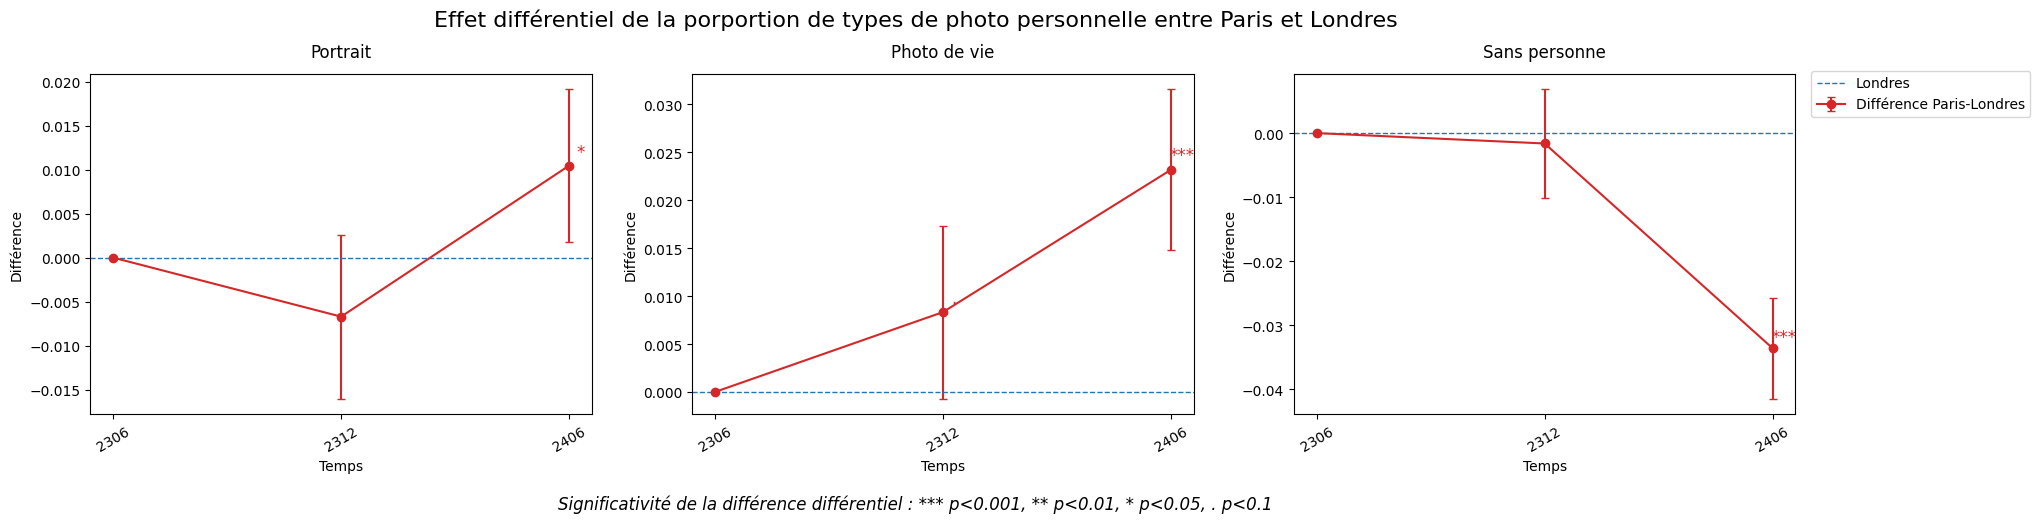

In [186]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --------------------layout 3 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(22,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=0.5)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


title_map={
    "is_portrait":'Portrait',
    "is_lifestyle":'Photo de vie',
    "no_person":'Sans personne',
}

for i, var in enumerate(tactics_pic):
    # plot_one_did(data=data_all, axes=axes, i=i, var=var)   
    plot_one_did(data=diff_data_pic,axes=axes, i=i, var=var, title=title_map.get(var, ""))# title='Type de photo : portrait'

## ---legend 3facets----
fig.suptitle(
        "Effet différentiel de la porportion de types de photo personnelle entre Paris et Londres",
        fontsize=16,
        y=1.01
    )

handles, labels =axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.01, 0.9)
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence différentiel : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.95, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

In [160]:
importlib.reload(modeling_did)
from utils.modeling_did import get_cf_data, run_tactic_model_by_time, plot_one_cf

agg_all_pic=[]
for var in tactics_pic:    
    print(var)
    model_tactic=run_tactic_model_by_time(df, y=var)
    agg=get_cf_data(df, model_tactic, var=var)
    display(agg)
    agg_all_pic.append(agg)    
agg_all_pic=pd.concat(agg_all_pic, axis=0)

is_portrait
ddd of is_portrait: 0.017153683642751737


,in_paris,time,y_hat,y_cf,variable
0,0,2306,0.329871,0.329871,is_portrait
1,0,2312,0.331419,0.331419,is_portrait
2,0,2406,0.327503,0.327503,is_portrait
3,1,2306,0.379533,0.379533,is_portrait
4,1,2312,0.371682,0.371682,is_portrait
5,1,2406,0.386305,0.369151,is_portrait


is_lifestyle
ddd of is_lifestyle: 0.014838140513398013


,in_paris,time,y_hat,y_cf,variable
0,0,2306,0.323496,0.323496,is_lifestyle
1,0,2312,0.315251,0.315251,is_lifestyle
2,0,2406,0.299121,0.299121,is_lifestyle
3,1,2306,0.294581,0.294581,is_lifestyle
4,1,2312,0.295208,0.295208,is_lifestyle
5,1,2406,0.294479,0.279640,is_lifestyle


no_person
ddd of no_person: -0.03199182415614951


,in_paris,time,y_hat,y_cf,variable
0,0,2306,0.346633,0.346633,no_person
1,0,2312,0.353331,0.353331,no_person
2,0,2406,0.373375,0.373375,no_person
3,1,2306,0.325887,0.325887,no_person
4,1,2312,0.333110,0.333110,no_person
5,1,2406,0.319216,0.351208,no_person


In [38]:
display(ddd_pic)

ddd_sig=ddd_pic[ddd_pic['variable']==var]['sig'].iloc[0]
print(var,ddd_sig)

,variable,coef,se,pval,sig,ci_low,ci_high
0,is_portrait,0.017154,0.004337,7.652006e-05,***,0.008653,0.025654
0,is_lifestyle,0.014838,0.004201,4.121373e-04,***,0.006605,0.023072
0,no_person,-0.031992,0.003934,4.268024e-16,***,-0.039703,-0.024280


is_portrait ***


axis x : [0, 1, 2]
axis x : [0, 1, 2]
axis x : [0, 1, 2]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\2329002110.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]


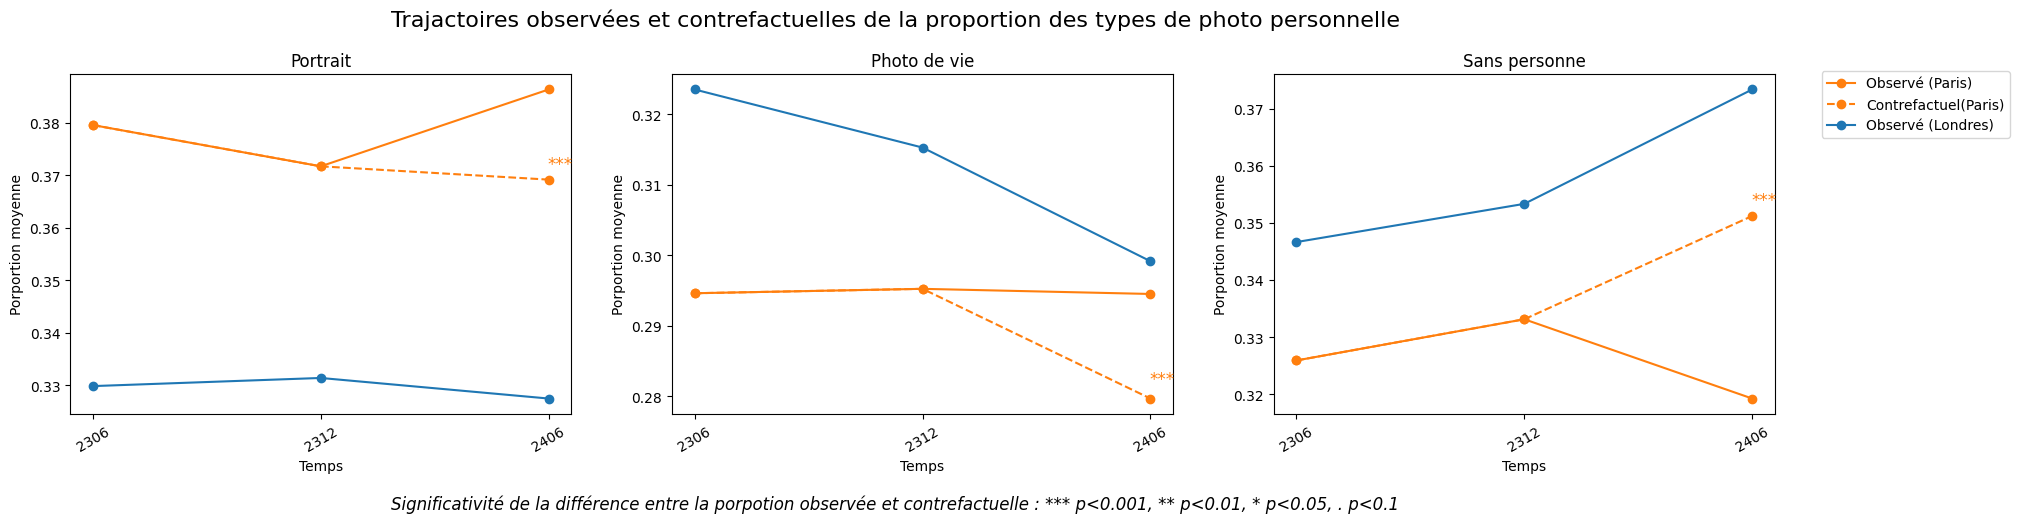

In [165]:


# --------------------layout 3 facets-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(22,5))# sharey=True
gs = gridspec.GridSpec(1, 6, figure=fig, hspace=0.4, wspace=0.5)
axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])


title_map={
    "is_portrait":'Portrait',
    "is_lifestyle":'Photo de vie',
    "no_person":'Sans personne',
}

# ---plot---
for i, var in enumerate(tactics_pic):
    # plot_one_did(data=data_all, axes=axes, i=i, var=var)   
    # plot_one_did(data=diff_data_pic,axes=axes, i=i, var=var, title=title_map.get(var, ""))# title='Type de photo : portrait'
    ddd_sig=ddd_pic[ddd_pic['variable']==var]['sig'].iloc[0]
    plot_one_cf(agg_all=agg_all_pic, axes=axes, i=i,  var=var, ddd_sig=ddd_sig, title=title_map.get(var,""), ylabel="Porportion moyenne")


## ---legend 3facets----
fig.suptitle(
    "Trajactoires observées et contrefactuelles de la proportion des types de photo personnelle",
    fontsize=16,
    y=1.01
    )

handles, labels =axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.01, 0.9)
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence entre la porpotion observée et contrefactuelle : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",

    # "Significativité de la différence de porportion: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.9, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## 2406 paris portrait占比上升，no_person下降，lifestyle几乎不变


# booking_rate~

In [171]:

df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) +"
        
        "ouverture + authenticité + sociabilité + auto_promotion + exemplarité +"
        "C(host_picture_type) +"
        "C(time) + in_paris*C(time)"
)
df=df_all.copy()
model_basic=smf.ols(formula, data=df).fit()
summary=model_basic.summary()
print(summary)


                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.399
Model:                            OLS   Adj. R-squared:                  0.399
Method:                 Least Squares   F-statistic:                     5209.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:53:18   Log-Likelihood:                 88301.
No. Observations:              266852   AIC:                        -1.765e+05
Df Residuals:                  266817   BIC:                        -1.762e+05
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [172]:
importlib.reload(modeling_did)
from utils.modeling_did import get_event_study_data, get_ddd_effect


var="booking_rate_l90d"
data_booking=get_event_study_data(model=model_basic, var=var)
display(data_booking)
print(data_booking.time.dtype)
ddd=get_ddd_effect(model=model_basic, var=var)
ddd


,time,coef,ci_low,ci_high,variable,se,pval,sig,label
0,2306,0.000000,0.000000,0.000000,booking_rate_l90d,NaN,NaN,,2306
1,2312,-0.030423,-0.033922,-0.026924,booking_rate_l90d,0.001785,4.303327e-65,***,2312 ***
2,2406,-0.058139,-0.061395,-0.054884,booking_rate_l90d,0.001661,9.234794e-268,***,2406 ***


object
booking_rate_l90d


,variable,coef,se,pval,sig,ci_low,ci_high
0,booking_rate_l90d,-0.027717,0.001631,1.024722e-64,***,-0.030914,-0.02452


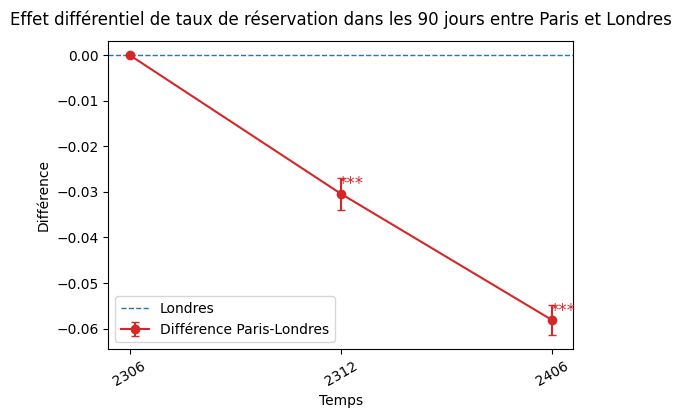

In [181]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did

plot_one_did(data_booking, axes=None, i=0, var='booking_rate_l90d', title='Effet différentiel de taux de réservation dans les 90 jours entre Paris et Londres')


In [188]:
# df['time']=df['time'].astype(str)
importlib.reload(modeling_did)
from utils.modeling_did import get_cf_data, get_ddd_effect

var="booking_rate_l90d"
agg_all=get_cf_data(df, model_basic, var=var)
ddd=get_ddd_effect(model=model_basic, var=var)

display(agg_all)
display(ddd)


ddd of booking_rate_l90d: -0.027716668465284693
booking_rate_l90d


,in_paris,time,y_hat,y_cf,variable
0,0,2306,0.162585,0.162585,booking_rate_l90d
1,0,2312,0.072095,0.072095,booking_rate_l90d
2,0,2406,0.119446,0.119446,booking_rate_l90d
3,1,2306,0.213811,0.213811,booking_rate_l90d
4,1,2312,0.102370,0.102370,booking_rate_l90d
5,1,2406,0.076108,0.103825,booking_rate_l90d


,variable,coef,se,pval,sig,ci_low,ci_high
0,booking_rate_l90d,-0.027717,0.001631,1.024722e-64,***,-0.030914,-0.02452


***
axis x : [0, 1, 2]


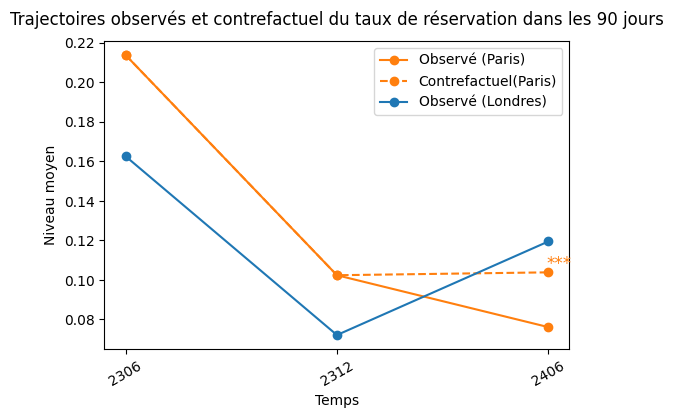

In [189]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_cf

ddd_sig=ddd[ddd['variable']==var]['sig'].loc[0]
print(ddd_sig)

plot_one_cf(agg_all, axes=None, i=0,  var=var, ddd_sig=ddd_sig, title='Trajectoires observés et contrefactuel du taux de réservation dans les 90 jours')

## 预订率实际下降
## jo有消极效果（房东无经验？很多房东没有受到avis pendant jo，竞争激烈）


## new & old hosts!

In [ ]:
## test_desc_host
## 已知authen， auto，exem在jo更多，ouv，socio更少
# jo对所有策略水平都有提升作用，否则它们的水平应该更低

## portrait占比增加，noperson占比减少
# jo增加portrait和lifestyle，减少noperson

# 源于谁？

# 策略整体效果(无交互)：ouv无，authen，socio积极，auto消极，exem积极
# 交互显示：jo让ouv，authe， socio更消极，auto和exem更积极***
# 但是实际水平，ouv无，authen，socio被压抑变成无，auto被提升至无，exem无
# jo让自我展示策略失效了？？？？？？？？？？？


## 整体而言：（柱状图）新房东更多使用ouv，authe， socio，旧房东更多使用auto和exem
# choc?（=>折线图）
# 左右比较新老房东:1)新房东的使用各个策略很平均，老房东更有针对性地策略，更注重auto，exe更高

# 老房东有策略的使用auto，exem符合他们的经验，但auto反而对预订率不利:(( exem有积极效果
# 新房东更强调个人，使用前三更多，平时有积极效果

# 2)看具体数值：老房东的策略策略性表现在2406使用更多auto（策略效果比以前更加积极，但在jo变得无显著）减少其他其余的***
# 新房东唯独没有使用更多的auto， 使用更多authen+socio+exem，减少ouv（策略效果比以前更加消极，变得不显著）

# 上下比较paris london：london的新老房东几乎没有显著改变策略，因为他们没有受到冲击，paris大部分改变，收到冲击！






## effets des tactiques globaux!

In [37]:
importlib.reload(modeling_did)
from utils.modeling_did import plot_predict_curve

pred_df= plot_predict_curve(model, df,  var="authenticité")
pred_df.head()

default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'in_paris': np.int64(0)}


,host_identity_verified,host_is_superhost,host_response_time,room_type,instant_bookable,time,review_scores_rating,has_rating,number_of_reviews_ltm,years_since_host,...,lang_en,lang_fr,text_length,price,availability_90,in_paris,authenticité,y,low,high
0,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-2.053085,0.165655,0.154678,0.176631
1,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-2.014349,0.165655,0.154678,0.176631
2,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-1.975614,0.165655,0.154678,0.176631
3,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-1.936879,0.165655,0.154678,0.176631
4,t,f,within an hour,Entire home/apt,f,2406,4.735862,1,8.702948,6.897913,...,0,0,31,236.310682,49.34868,0,-1.898144,0.165655,0.154678,0.176631


default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'host_picture_type': 'pro_style', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'ouverture': np.float64(-0.10035002037640012), 'authenticité': np.float64(-0.1766306637850288), 'sociabilité': np.float64(-0.06570151372882968), 'auto_promotion': np.float64(0.1525097733332789), 'exemplarité': np.float64(0.03377935753765357), 'in_paris': np.int64(0)}
default_vals: {'host_iden

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax


default_vals: {'host_identity_verified': 't', 'host_is_superhost': 'f', 'host_response_time': 'within an hour', 'room_type': 'Entire home/apt', 'instant_bookable': 'f', 'host_picture_type': 'pro_style', 'time': '2406', 'review_scores_rating': np.float64(4.735862013400686), 'has_rating': np.int64(1), 'number_of_reviews_ltm': np.float64(8.702947701347563), 'years_since_host': np.float64(6.897913450152144), 'professional_host': np.int64(0), 'host_response_rate': np.float64(0.7873780972224305), 'has_text': np.int64(0), 'lang_en': np.int64(0), 'lang_fr': np.int64(0), 'text_length': np.float64(31.178567145833647), 'price': np.float64(236.31068157630446), 'availability_90': np.float64(49.34868016728374), 'ouverture': np.float64(-0.10035002037640012), 'authenticité': np.float64(-0.1766306637850288), 'sociabilité': np.float64(-0.06570151372882968), 'auto_promotion': np.float64(0.1525097733332789), 'exemplarité': np.float64(0.03377935753765357), 'in_paris': np.int64(0)}
default_vals: {'host_iden

C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()#on ax
C:\Users\yeliu\AppData\Local\Temp\ipykernel_15236\3106577990.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


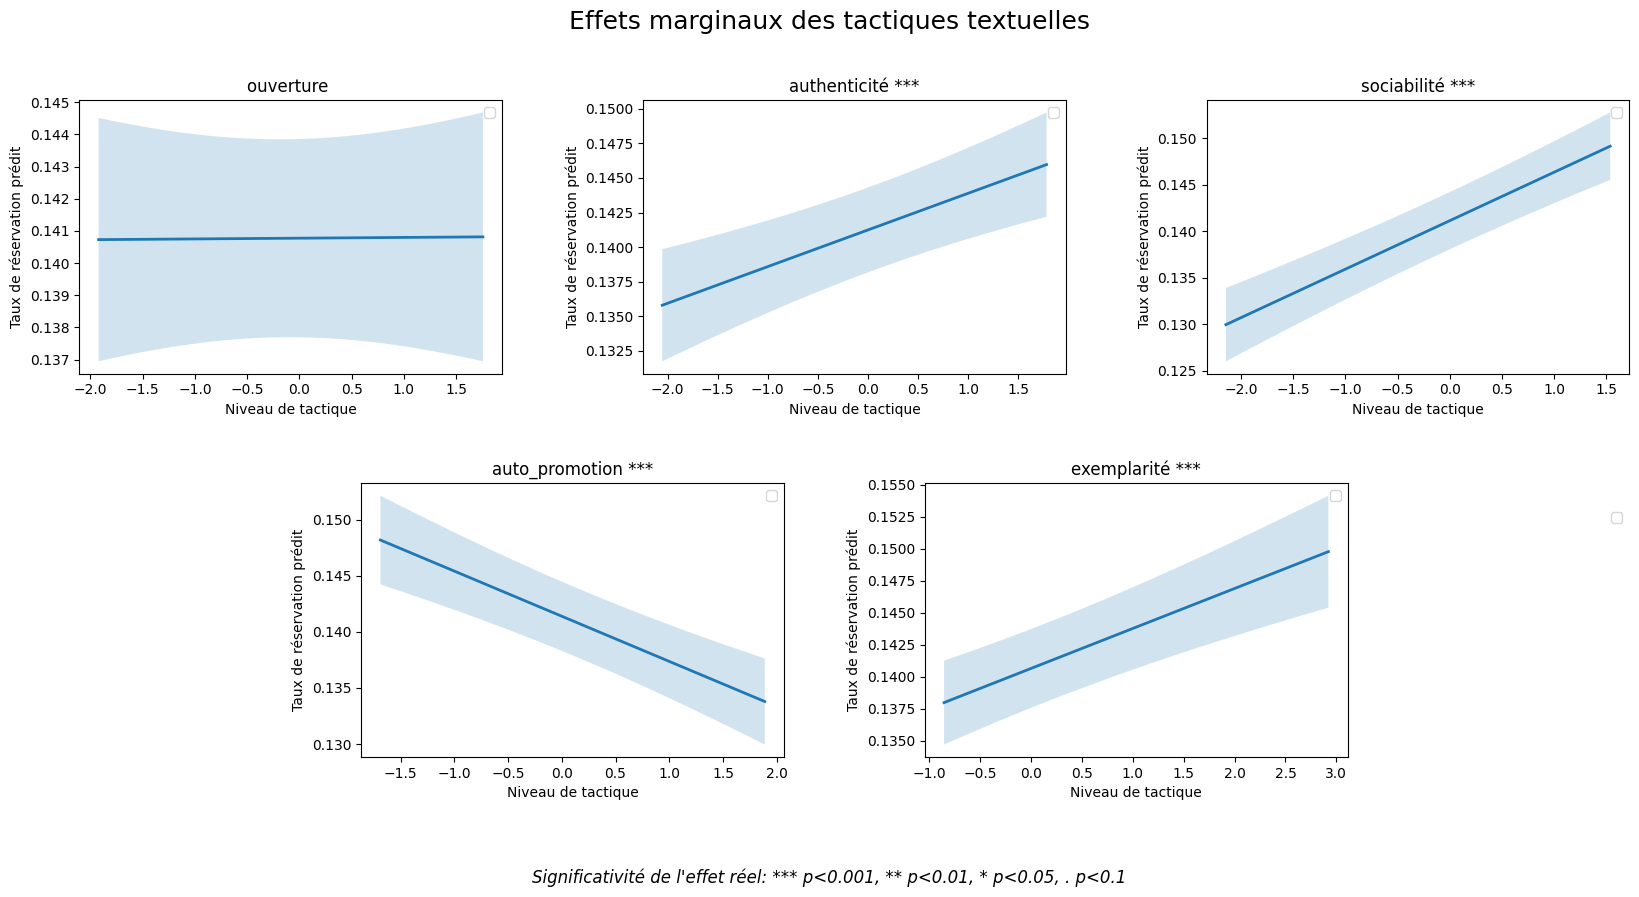

In [ ]:
df=df_all.copy()
model=model_basic

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))


# city='paris'
# times=['2024',"2023"]


for i, var in enumerate(tactics_bio):
    ax = axes[i]
    # for time in times:
    pred_df = plot_predict_curve(model, df, var)
    sig=p_to_sig(model.pvalues[var])
    
    ax.plot(pred_df[var], pred_df["y"], linewidth=2)
    ax.fill_between(pred_df[var], pred_df["low"], pred_df["high"], alpha=0.2)
    ax.legend()#on ax
    ax.set_title(f"{var} {sig}")
    ax.set_xlabel("Niveau de tactique")
    ax.set_ylabel("Taux de réservation prédit")


# --------------------legend------------------------
fig.suptitle(
    "Effets marginaux des tactiques textuelles",
    fontsize=18,
    y=0.98 #大标题到子图的距离
)

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.43)# legend (x, y)
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()
# --------------------------------------------
# 整体上, ouv不显著，authen，socio，exem积极，auto消极


In [41]:
def plot_categorical_effect(model, df, var, sample_n=5000):
    import pandas as pd
    
    # 抽样（关键！）
    base = df.sample(sample_n, random_state=0).copy()
    
    categories = df[var].dropna().unique()
    
    results = []
    for cat in categories:
        # print(cat)
        
        base[var] = cat
        yhat = model.predict(base)   # 🚀 快很多
        term=f"C({var})[T.{cat}]"
        
        if term not in list(model.params.index):
            sig = ""
        else:   
            sig = p_to_sig(float(model.pvalues[term]))
        
        results.append({
            "variable":var,
            "category": cat,
            "y": yhat.mean(),
            "sig": sig
        })
    return pd.DataFrame(results)

pred_df = plot_categorical_effect(model_basic, df, var="host_picture_type")
display(pred_df)


,variable,category,y,sig
0,host_picture_type,life_style,0.116065,
1,host_picture_type,pro_style,0.118392,**
2,host_picture_type,no_person,0.109621,***


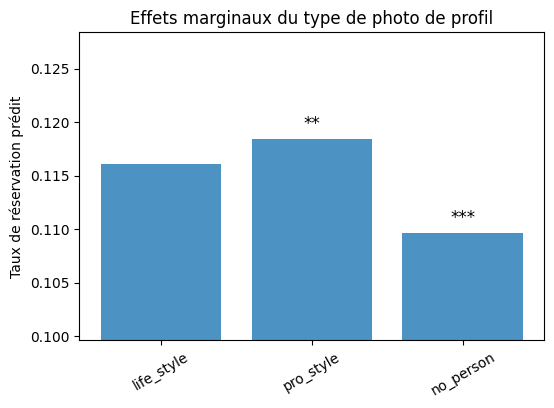

In [ ]:
def plot_cat_effect(df_plot):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,4))

    ax = plt.gca()

    ax.bar(df_plot["category"], df_plot["y"], alpha=0.8)

    for i, row in df_plot.iterrows():
        ax.text(i, row["y"] + 0.001, row["sig"],
                ha='center', fontsize=12)
    
    ax.set_ylabel("Taux de réservation prédit")
    ax.set_title("Effets marginaux du type de photo de profil")
    ax.tick_params(axis="x", rotation=30)

    plt.ylim(min(df_plot["y"]) - 0.01, max(df_plot["y"]) + 0.01)
    plt.show()
plot_cat_effect(pred_df)

# 相比于基准组lifestyle，pro积极，no_person消极



,variable,category,y,sig
0,host_is_superhost,f,0.113674,
1,host_is_superhost,t,0.119241,***


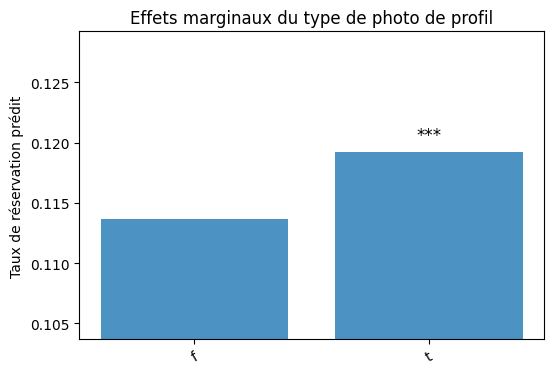

In [ ]:
# pred_df = plot_categorical_effect(model_basic, df, var="host_is_superhost")
# display(pred_df)
# plot_cat_effect(pred_df)

## model inetraction

In [193]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

import statsmodels.api as sm
import statsmodels.formula.api as smf

from utils import modeling_did
tactics_bio=[
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
]
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''

# path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406.csv"
# df_all=pd.read_csv(path_df)
# print(df_all.shape)

In [194]:
df_all[tactics_bio]=df_all[tactics_bio].fillna(0)
df_all["host_picture_type"]=df_all["host_picture_type"].fillna("no_person")

print(df_all[tactics_bio].isna().value_counts())
print(df_all["host_picture_type"].isna().value_counts())


ouverture  authenticité  sociabilité  auto_promotion  exemplarité
False      False         False        False           False          266852
Name: count, dtype: int64
host_picture_type
False    266852
Name: count, dtype: int64


In [195]:
df=df_all.copy()
formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "C(host_picture_type) +"
        "C(time) +"
        "in_paris * C(time) *(C(host_picture_type) + ouverture + authenticité + sociabilité + auto_promotion + exemplarité)"
      
)
df=df_all.copy()
model_interaction=smf.ols(formula, data=df).fit()
summary=model_interaction.summary()
print(summary)

                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.402
Model:                            OLS   Adj. R-squared:                  0.402
Method:                 Least Squares   F-statistic:                     2601.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        21:49:22   Log-Likelihood:                 89010.
No. Observations:              266852   AIC:                        -1.779e+05
Df Residuals:                  266782   BIC:                        -1.771e+05
Df Model:                          69                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

### effets réels des tactiques dans les groups

In [196]:
importlib.reload(modeling_did)
from utils.modeling_did import get_real_cf_effect_data
tactics_vars=["authenticité"]

ddd=results = pd.concat([
    get_ddd_effect_interaction(model=model_interaction, var=var)
    for var in tactics_vars
])

df_plot=get_real_cf_effect_data(model=model_interaction, tactics=tactics_vars, ddd_df=ddd)
display(ddd)
display(df_plot)


authenticité


,variable,coef,se,pval,sig,ci_low,ci_high
0,authenticité,-0.010129,0.003037,0.000854,***,-0.016082,-0.004175


,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high
0,2306,0,authenticité,0.009019,0.009019,0.001487,1.315256e-09,***,0.006105,0.011933
1,2312,0,authenticité,-0.005589,-0.005589,0.001509,2.132456e-04,***,-0.008547,-0.002631
2,2406,0,authenticité,0.003519,0.003519,0.001411,1.265763e-02,*,0.000753,0.006285
3,2306,1,authenticité,0.013192,0.013192,0.001730,2.420286e-14,***,0.009801,0.016582
4,2312,1,authenticité,0.000148,0.000148,0.001767,9.332312e-01,,-0.003314,0.003610
5,2406,1,authenticité,-0.000873,0.009256,0.001411,5.361321e-01,,-0.003638,0.001892


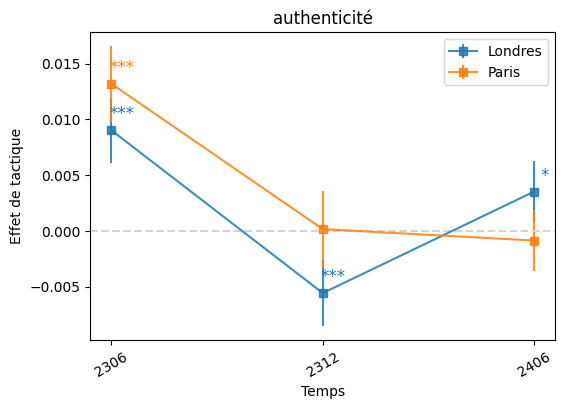

In [197]:
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo, plot_one_real_effect

# var="C(host_picture_type)[T.no_person]"
var="authenticité"
plot_one_real_effect(df_plot=df_plot, var=var)


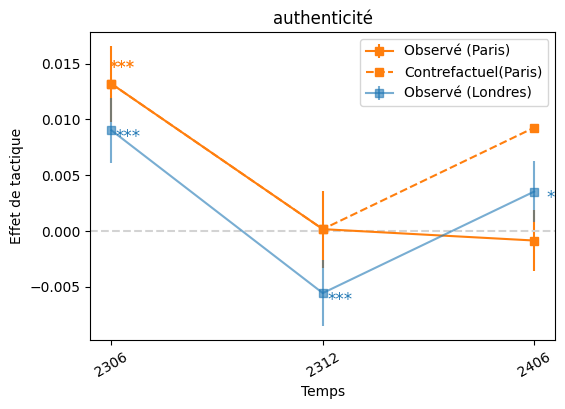

In [198]:
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo, plot_one_real_cf_effect

var="authenticité"
plot_one_real_cf_effect(df_plot, var, axes=None, i=0, title=None)


In [199]:

importlib.reload(modeling_did)
from utils.modeling_did import get_real_cf_effect_data, get_ddd_effect_interaction

tactics_vars=[
    'ouverture',
    "authenticité",
    "sociabilité",
    'auto_promotion',
    "exemplarité",
    'C(host_picture_type)[T.no_person]',
    'C(host_picture_type)[T.pro_style]',
]
ddd=results = pd.concat([
    get_ddd_effect_interaction(model=model_interaction, var=var)
    for var in tactics_vars
])


df_plot=get_real_cf_effect_data(model=model_interaction, tactics=tactics_vars, ddd_df=ddd)
display(ddd)
display(df_plot)


ouverture
authenticité
sociabilité
auto_promotion
exemplarité
C(host_picture_type)[T.no_person]
C(host_picture_type)[T.pro_style]


,variable,coef,se,pval,sig,ci_low,ci_high
0,ouverture,-0.003793,0.002994,0.205081,,-0.009661,0.002074
0,authenticité,-0.010129,0.003037,0.000854,***,-0.016082,-0.004175
0,sociabilité,-0.003074,0.002907,0.290375,,-0.008772,0.002624
0,auto_promotion,0.002930,0.003018,0.331754,,-0.002986,0.008846
0,exemplarité,0.001896,0.002783,0.495737,,-0.003559,0.007350
0,C(host_picture_type)[T.no_person],0.016284,0.004194,0.000103,***,0.008064,0.024503
0,C(host_picture_type)[T.pro_style],-0.004110,0.004022,0.306761,,-0.011993,0.003772


,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high
0,2306,0,ouverture,0.000727,0.000727,0.001471,6.213242e-01,,-0.002156,0.003610
1,2312,0,ouverture,0.000103,0.000103,0.001491,9.449522e-01,,-0.002819,0.003025
2,2406,0,ouverture,0.003065,0.003065,0.001405,2.913877e-02,*,0.000311,0.005819
3,2306,1,ouverture,-0.005281,-0.005281,0.001725,2.205614e-03,**,-0.008662,-0.001899
4,2312,1,ouverture,-0.000925,-0.000925,0.001763,5.996478e-01,,-0.004380,0.002529
5,2406,1,ouverture,-0.001756,0.002037,0.001367,1.987189e-01,,-0.004435,0.000922
6,2306,0,authenticité,0.009019,0.009019,0.001487,1.315256e-09,***,0.006105,0.011933
7,2312,0,authenticité,-0.005589,-0.005589,0.001509,2.132456e-04,***,-0.008547,-0.002631
8,2406,0,authenticité,0.003519,0.003519,0.001411,1.265763e-02,*,0.000753,0.006285
9,2306,1,authenticité,0.013192,0.013192,0.001730,2.420286e-14,***,0.009801,0.016582


In [ ]:

df_plot[(df_plot['time']=="2406")&(df_plot['in_paris']==1)]
#❗你的结果不是“这些策略在 2406 Paris 没有效果”，Paris 的策略 effect 难以被稳定识别
# effect ≠ 0（有方向）
# 但 SE 大 → CI 很宽



,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high
5,2406,1,ouverture,-0.001756,0.002037,0.001367,0.198719,,-0.004435,0.000922
11,2406,1,authenticité,-0.000873,0.009256,0.001411,0.536132,,-0.003638,0.001892
17,2406,1,sociabilité,0.001823,0.004896,0.001345,0.175366,,-0.000813,0.004459
23,2406,1,auto_promotion,-0.000408,-0.003338,0.001439,0.776659,,-0.003229,0.002413
29,2406,1,exemplarité,-0.001056,-0.002952,0.001218,0.386018,,-0.003444,0.001332
35,2406,1,C(host_picture_type)[T.no_person],0.006079,-0.010205,0.001894,0.001332,**,0.002366,0.009793
41,2406,1,C(host_picture_type)[T.pro_style],0.003061,0.007171,0.001695,0.070996,.,-0.000262,0.006383


In [203]:
df_plot[(df_plot['time']=="2306")&(df_plot['in_paris']==0)]

,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high
0,2306,0,ouverture,0.000727,0.000727,0.001471,6.213242e-01,,-0.002156,0.003610
6,2306,0,authenticité,0.009019,0.009019,0.001487,1.315256e-09,***,0.006105,0.011933
12,2306,0,sociabilité,0.009050,0.009050,0.001378,5.135004e-11,***,0.006349,0.011751
18,2306,0,auto_promotion,-0.008000,-0.008000,0.001440,2.753697e-08,***,-0.010822,-0.005178
24,2306,0,exemplarité,0.009468,0.009468,0.001385,8.133716e-12,***,0.006754,0.012182
30,2306,0,C(host_picture_type)[T.no_person],-0.027667,-0.027667,0.002148,0.000000e+00,***,-0.031876,-0.023458
36,2306,0,C(host_picture_type)[T.pro_style],0.000896,0.000896,0.002088,6.679112e-01,,-0.003197,0.004989


In [207]:
df_plot[(df_plot['time']=="2406")&(df_plot['in_paris']==0)]

,time,in_paris,variable,effect_hat,effect_cf,se,pval,sig,ci_low,ci_high
2,2406,0,ouverture,0.003065,0.003065,0.001405,0.029139,*,0.000311,0.005819
8,2406,0,authenticité,0.003519,0.003519,0.001411,0.012658,*,0.000753,0.006285
14,2406,0,sociabilité,0.004873,0.004873,0.001315,0.000212,***,0.002294,0.007451
20,2406,0,auto_promotion,-0.003140,-0.003140,0.001390,0.023879,*,-0.005865,-0.000416
26,2406,0,exemplarité,0.002508,0.002508,0.001277,0.049499,*,0.000005,0.005011
32,2406,0,C(host_picture_type)[T.no_person],-0.007501,-0.007501,0.002005,0.000183,***,-0.011430,-0.003572
38,2406,0,C(host_picture_type)[T.pro_style],0.002862,0.002862,0.001969,0.146031,,-0.000997,0.006720


0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\4257536243.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


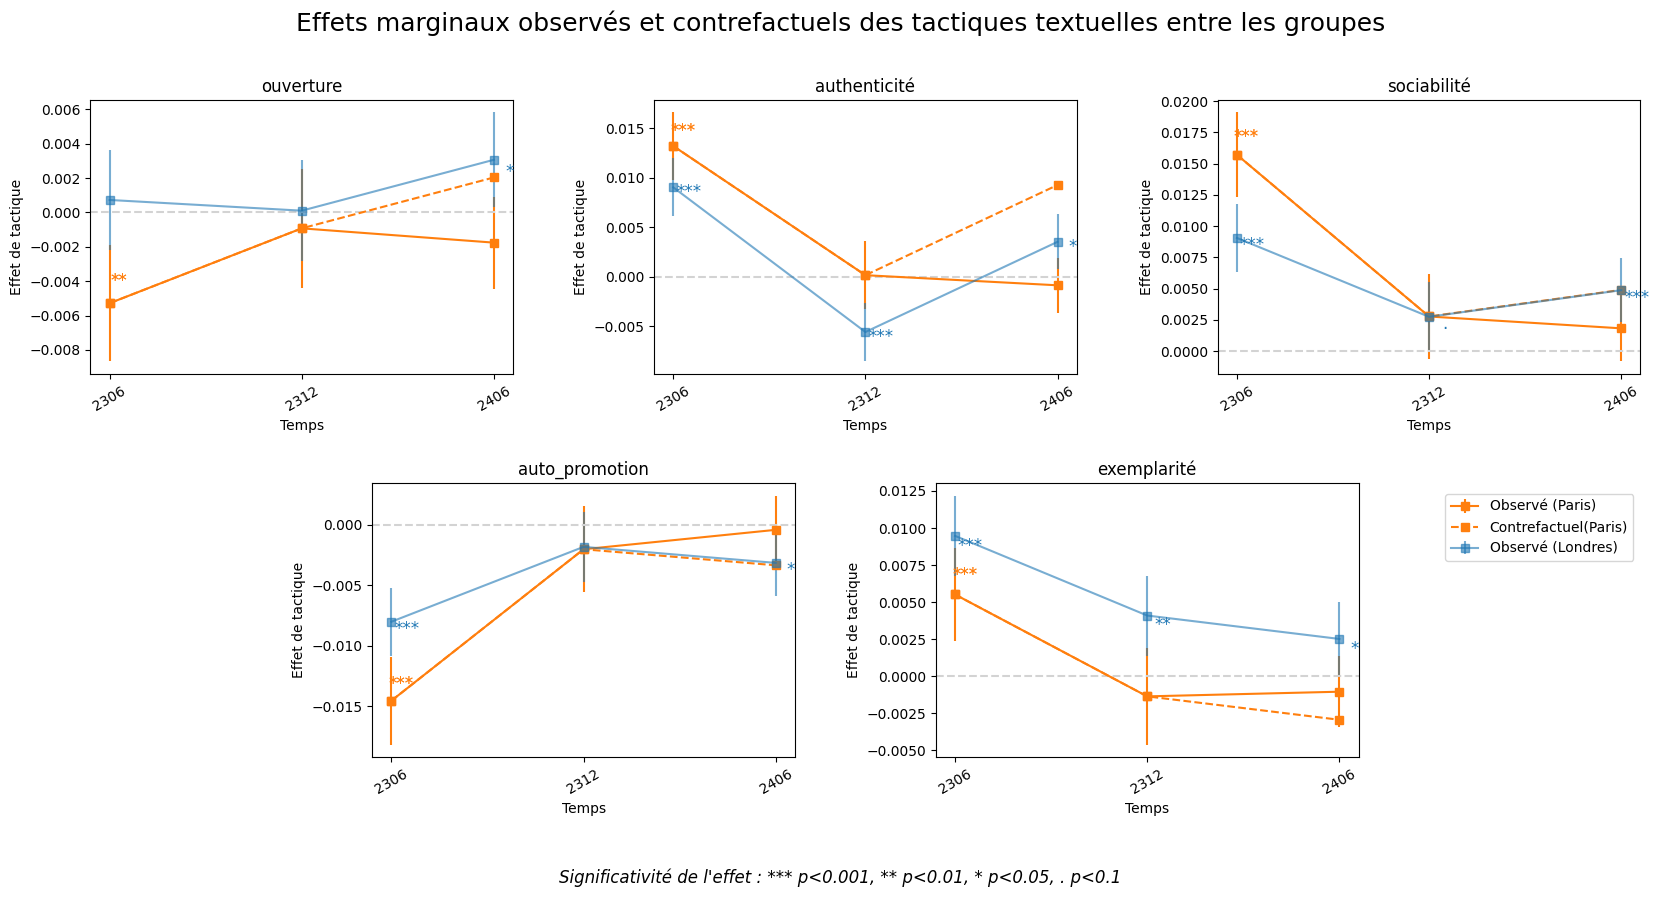

In [ ]:
import matplotlib.gridspec as gridspec
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo, plot_one_real_effect, plot_one_real_cf_effect


# df=df_all.copy()
# model=model_interaction

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# # 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

axes.extend([ax4, ax5])



# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))

# --------------------------------------------


## plot
for i, var in enumerate(tactics_bio):
    print(i, var)
    plot_one_real_cf_effect(df_plot=df_plot, var=var, axes=axes, i=i)
    # plot_one_real_effect(df_plot=df_plot, var=var, axes=axes, i=i)
    # 本来策略应该类似于london的趋势回弹？


# --------------------legend------------------------
fig.suptitle(
        "Effets marginaux observés et contrefactuels des tactiques textuelles entre les groupes",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()
# --------------------------------------------



### todo:
# ps. star represents the significance of the tactic at this point in this city✔
# legend remove✔
# + contrefactual?? auto+socio积极策略受到消极影响，消极策略auto受到积极效果✔
# 虚线在上说明受到消极影响，虚线在下说明有积极影响

## 新房东专注于authen+socio??

# 补上ddd✔

# 新老房东的booking 
# 新房东的描述：不一定是全新的房东，而是reactivated host

# try is_smiling, age, gender...



# -----------------------RESULT---------------------------
# 
# jo让所有策略水平上升，但实际水平auth，auto，exem上升，ouv，socio下降
# jo时策略的实际效果，ouv，authen，socio下降，auto和exem上升 (2312vs 2406)
# jo削弱ouv，authe， socio，轻微提升auto和exem (虚线vs实现)

# 为什么效果也会回弹？

0 C(host_picture_type)[T.no_person]
1 C(host_picture_type)[T.pro_style]


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\2476945507.py:56: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.95, 1])# [left, bottom, right, top]


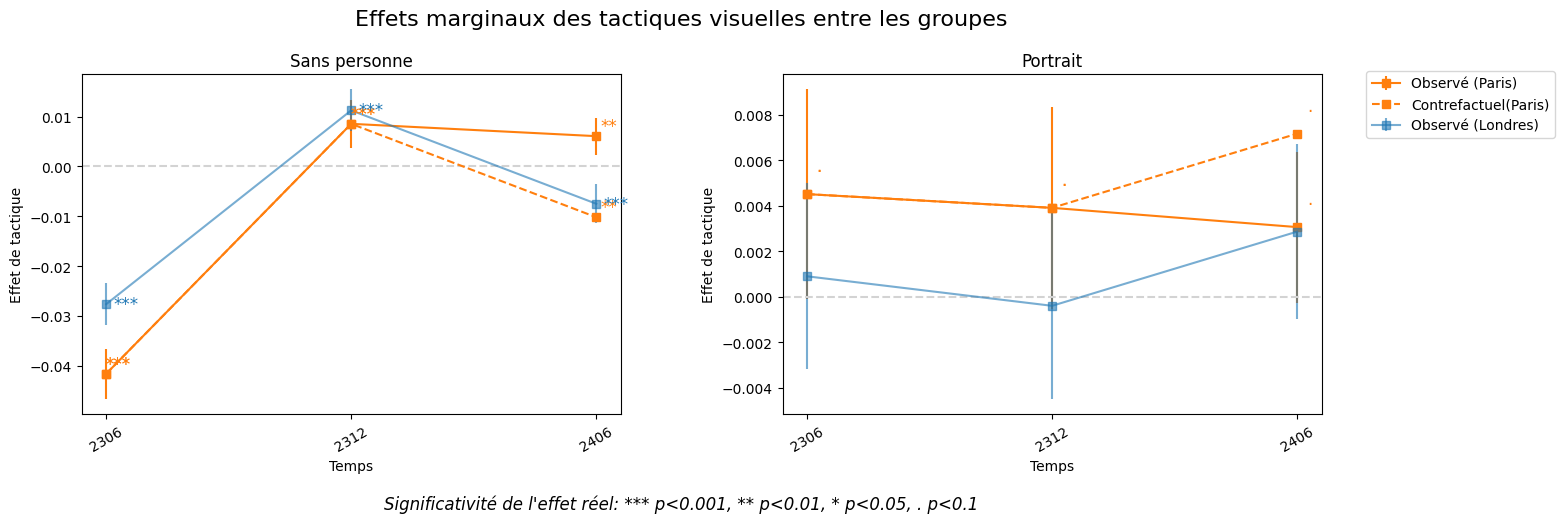

In [112]:
import matplotlib.gridspec as gridspec
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo, plot_one_real_effect


## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


## plot
tactics_pic=[
 'C(host_picture_type)[T.no_person]',
 'C(host_picture_type)[T.pro_style]'
]
title_pic=['Sans personne', 'Portrait']

title_map=dict(zip(tactics_pic, title_pic))

for i, var in enumerate(tactics_pic):
    print(i, var)
    plot_one_real_cf_effect(df_plot=df_plot, axes=axes, i=i, var=var, title=title_map.get(var,""))



## ---legend 2facets----
fig.suptitle(
        "Effets marginaux des tactiques visuelles entre les groupes",
        fontsize=16,
        y=1.01
    )

handles, labels =axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.05, 0.9)
)

plt.figtext(
    0.5, 0.01,
    "Significativité de l'effet réel: *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.95, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## 压制portrait，提升no person
# 和文本策略类似：提高质量变量，不重视人物线相关变量


In [129]:
## 为什么策略在2406变得全部不显著？？？
sub_df=df_all[(df_all['time']=="2406")&(df_all['in_paris']==1)].copy()
print(sub_df.shape)
print(sub_df[['time','in_paris']].value_counts(dropna=False))

formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
        "number_of_reviews_ltm + "
        "C(host_is_superhost) +"
        "years_since_host + professional_host + "
        "host_response_rate +  +C(host_response_time)+"
        "has_text + lang_en + lang_fr + text_length+"
        "price  + availability_90 + C(room_type) + C(instant_bookable) + "
        "C(host_picture_type) +"
        "C(time) +"
        "in_paris * C(time) *(C(host_picture_type) + ouverture + authenticité + sociabilité + auto_promotion + exemplarité)"
      
)  
        # "pic_no_person + pic_pro_style + pic_life_style +"
        # " is_smiling + "
        # "C(age_class) + C(gender) +"

sub_model=smf.ols(formula, data=sub_df).fit()
summary=sub_model.summary()
print(summary)


(62738, 125)
time  in_paris
2406  1           62738
Name: count, dtype: int64
                            OLS Regression Results                            
Dep. Variable:      booking_rate_l90d   R-squared:                       0.350
Model:                            OLS   Adj. R-squared:                  0.349
Method:                 Least Squares   F-statistic:                     1162.
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:58:26   Log-Likelihood:                 39092.
No. Observations:               62738   AIC:                        -7.812e+04
Df Residuals:                   62708   BIC:                        -7.785e+04
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------

In [142]:
tactics_vars=[
    'ouverture',
    "authenticité",
    "sociabilité",
    'auto_promotion',
    "exemplarité",
    'C(host_picture_type)[T.no_person]',
    'C(host_picture_type)[T.pro_style]',
]
times=df_all['time'].unique()
in_paris=df_all["in_paris"].unique()
# print(times, in_paris)

rows=[]
for t in times :
    for p in in_paris:
        print(f"time={t}, in_paris={p}")
        
        sub_df=df_all[(df_all['time']==t)&(df_all['in_paris']==p)].copy()
        # print(sub_df.shape)
        # print(sub_df[['time','in_paris']].value_counts(dropna=False))

        formula= ("booking_rate_l90d ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  +C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "C(host_picture_type) +"
                "C(time) +"
                "in_paris * C(time) *(C(host_picture_type) + ouverture + authenticité + sociabilité + auto_promotion + exemplarité)"
            
        )  
        sub_model=smf.ols(formula, data=sub_df).fit()
        # print(sub_model.summary())
        for var in tactics_vars:
            rows.append({
                'time':t,
                'in_paris':p,
                "variable":var,
                'coef':sub_model.params[var],
                'pval':sub_model.pvalues[var],
                "sig":p_to_sig(sub_model.pvalues[var])
            })
    #     break
    # break

rows_df=pd.DataFrame(rows)
rows_df=rows_df.sort_values(["time",'in_paris'])
display(rows_df)

time=2306, in_paris=0
time=2306, in_paris=1
time=2312, in_paris=0
time=2312, in_paris=1
time=2406, in_paris=0
time=2406, in_paris=1


,time,in_paris,variable,coef,pval,sig
0,2306,0,ouverture,-0.000827,6.287276e-01,
1,2306,0,authenticité,0.005319,2.409652e-03,**
2,2306,0,sociabilité,0.009638,3.349743e-09,***
3,2306,0,auto_promotion,-0.007121,7.350288e-05,***
4,2306,0,exemplarité,0.008508,1.390057e-07,***
5,2306,0,C(host_picture_type)[T.no_person],-0.013235,3.935652e-07,***
6,2306,0,C(host_picture_type)[T.pro_style],0.000408,8.659524e-01,
7,2306,1,ouverture,-0.001403,2.401568e-01,
8,2306,1,authenticité,0.002396,4.554798e-02,*
9,2306,1,sociabilité,0.006837,2.377683e-09,***


In [144]:
var="authenticité"

sub_rows_df=rows_df[rows_df['variable']==var]
sub_rows_df=sub_rows_df.sort_values(['in_paris','time'])
sub_rows_df

,time,in_paris,variable,coef,pval,sig
1,2306,0,authenticité,0.005319,0.002410,**
15,2312,0,authenticité,-0.001839,0.131091,
29,2406,0,authenticité,0.001989,0.138492,
8,2306,1,authenticité,0.002396,0.045548,*
22,2312,1,authenticité,0.001461,0.128835,
36,2406,1,authenticité,0.001301,0.019359,*


## JUST DID

In [ ]:
## 不需要包括in_paris:C(time)[T.2312]没有涉及到var!
# 真实效应的组成：
# london 2306: authenticité 
# london 2312 :  authenticité + C(time)[T.2312]:authenticité
# london 2406 :  authenticité + C(time)[T.2406]:authenticité

# paris 2306: authenticité + in_paris:authenticité
# paris 2312 : authenticité + in_paris:authenticité + C(time)[T.2312]: authenticité + in_paris:C(time)[T.2312]:authenticité
# paris 2406 : authenticité + in_paris:authenticité + C(time)[T.2406]: authenticité + in_paris:C(time)[T.2406]:authenticité

# delta 2306: in_paris:authenticité
# delta 2312 : in_paris:authenticité +  in_paris:C(time)[T.2312]:authenticité
# delta 2406 : in_paris:authenticité +  in_paris:C(time)[T.2312]:authenticité

# in_paris:authenticité重复！（设置为hline）?



In [208]:
# FOR CHECK
model=model_interaction
var="authenticité"
b_paris = model.params[f"in_paris:{var}"]
b_2312 = model.params.get(f"in_paris:C(time)[T.2312]:{var}", 0)
b_2406 = model.params.get(f"in_paris:C(time)[T.2406]:{var}", 0)
print('coef:',b_paris, b_2312, b_2406)

p_paris = model.pvalues[f"in_paris:{var}"]
p_2312 = model.pvalues.get(f"in_paris:C(time)[T.2312]:{var}", 0)
p_2406 = model.pvalues.get(f"in_paris:C(time)[T.2406]:{var}", 0)
print('pvalues:',p_paris, p_2312, p_2406)


# diff_2306 = b_paris
# diff_2312 = b_paris + b_2312
# diff_2406 = b_paris + b_2406

diff_2306 = 0
diff_2312 = b_2312
diff_2406 = b_2406
print('diff:', diff_2306, diff_2312, diff_2406)
print("ddd:", diff_2406-diff_2312)


coef: 0.004172958724902155 0.0015639002229617708 -0.00856469197903868
pvalues: 0.06616811955539265 0.6284086775283616 0.0043843274796398985
diff: 0 0.0015639002229617708 -0.00856469197903868
ddd: -0.01012859220200045


In [209]:
importlib.reload(modeling_did)
from utils.modeling_did import linear_combo
import numpy as np


results_did=[]
for var in tactics_vars:
    print(var)
    specs_did = [   
                # paris:
                ("2306", None),
                ("2312", [
                    # f"in_paris:{var}",
                    f"in_paris:C(time)[T.2312]:{var}", 
                ]),
                ("2406", [
                    # f"in_paris:{var}",
                    f"in_paris:C(time)[T.2406]:{var}", 
                ])  

            ]
    for time, terms in specs_did:    
        if time=="2306":#设置2306为基准线，但是保留se，pval
            results_did.append({
                "time":"2306",
                "variable":var,
                "effect": 0,
                "se": 0,
                "pval": np.nan,
                "sig":"",
                "ci_low": 0,
                "ci_high": 0
            })
        else :
            effect, se, pval, ci_low, ci_high = linear_combo(model=model_interaction, terms=terms)               
            results_did.append({
                "time":time,
                "variable":var,
                "effect": effect,
                "se": se,
                "pval": pval,
                "sig":p_to_sig(pval),
                "ci_low": ci_low,
                "ci_high": ci_high
            })
        
df_plot_did=pd.DataFrame(results_did)
display(df_plot_did)

ouverture
authenticité
sociabilité
auto_promotion
exemplarité
C(host_picture_type)[T.no_person]
C(host_picture_type)[T.pro_style]


,time,variable,effect,se,pval,sig,ci_low,ci_high
0,2306,ouverture,0.000000,0.000000,NaN,,0.000000,0.000000
1,2312,ouverture,0.004979,0.003202,1.199784e-01,,-0.001297,0.011255
2,2406,ouverture,0.001186,0.002962,6.889532e-01,,-0.004620,0.006991
3,2306,authenticité,0.000000,0.000000,NaN,,0.000000,0.000000
4,2312,authenticité,0.001564,0.003231,6.284087e-01,,-0.004770,0.007897
5,2406,authenticité,-0.008565,0.003006,4.384327e-03,**,-0.014457,-0.002673
6,2306,sociabilité,0.000000,0.000000,NaN,,0.000000,0.000000
7,2312,sociabilité,-0.006628,0.003128,3.407114e-02,*,-0.012759,-0.000498
8,2406,sociabilité,-0.009702,0.002889,7.835498e-04,***,-0.015364,-0.004040
9,2306,auto_promotion,0.000000,0.000000,NaN,,0.000000,0.000000


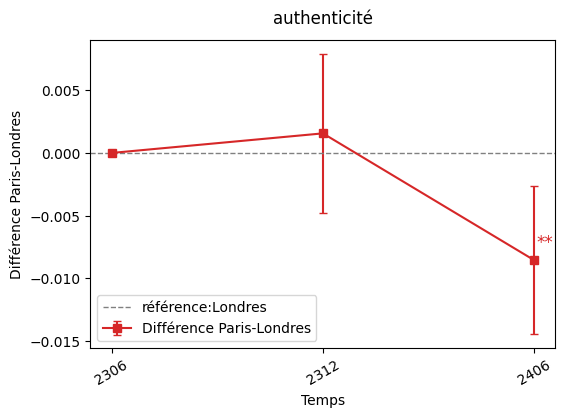

In [210]:

importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did_interaction

plot_one_did_interaction(df_plot=df_plot_did, var='authenticité')


0 ouverture
1 authenticité
2 sociabilité
3 auto_promotion
4 exemplarité


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\666801941.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


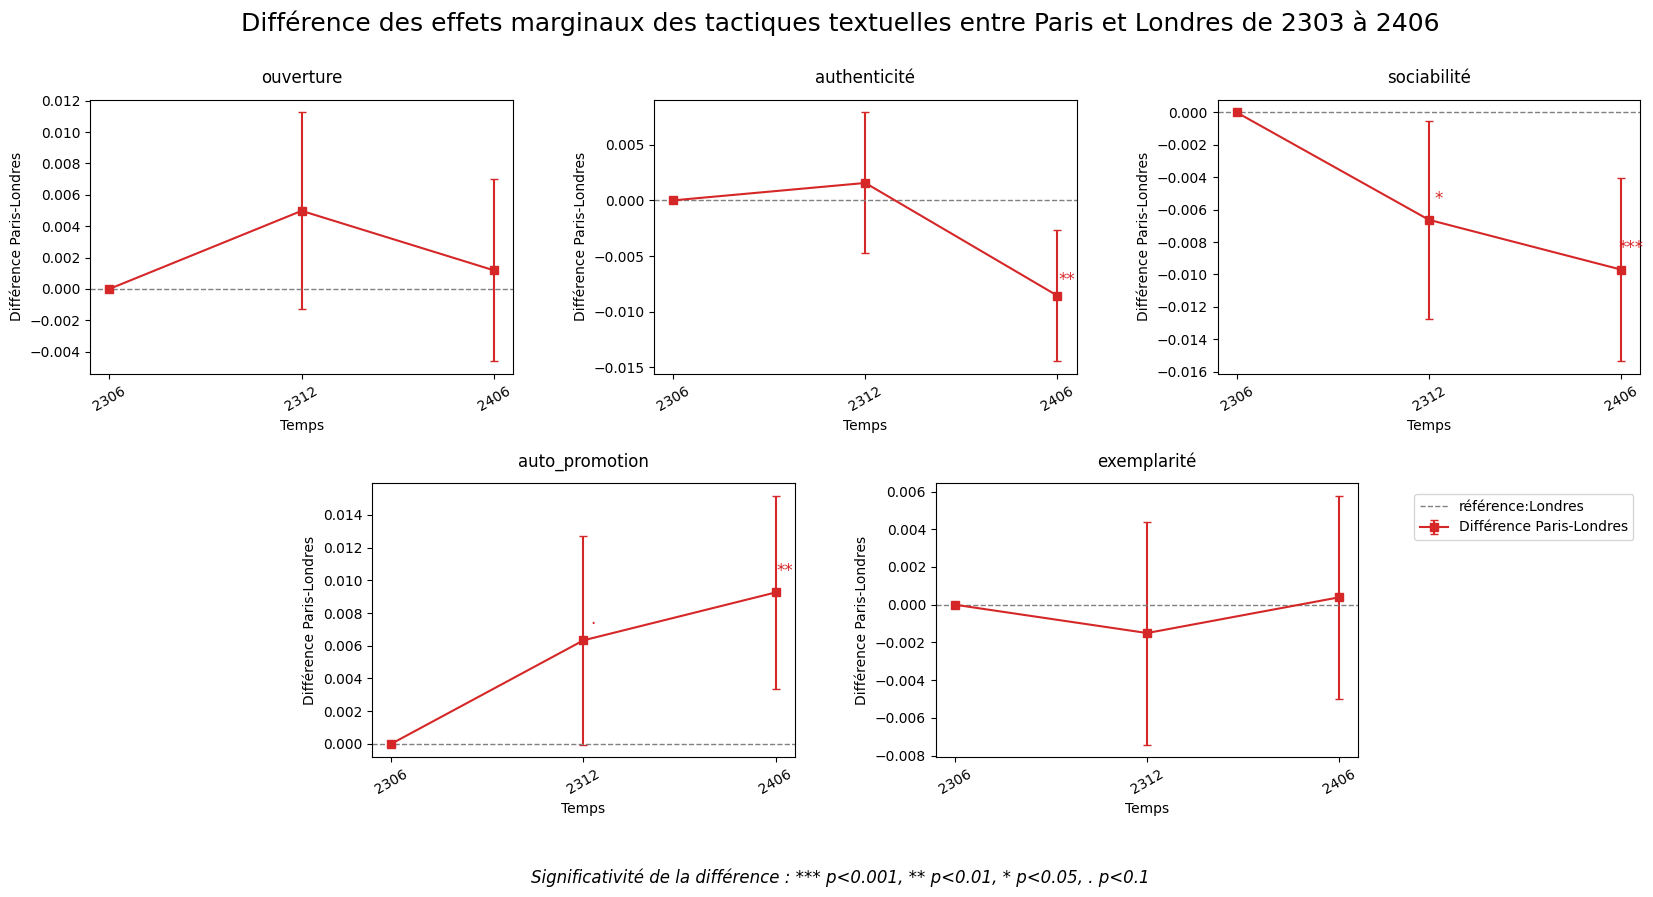

In [ ]:
import matplotlib.gridspec as gridspec
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did_interaction


# df=df_all.copy()
# model=model_interaction

# -------------------layout-------------------
# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
n_to_plot = min(len(tactics_bio), len(axes))

# --------------------------------------------


## plot
for i, var in enumerate(tactics_bio):
    print(i, var)
    plot_one_did_interaction(df_plot=df_plot_did, var=var, axes=axes, i=i)

fig.suptitle(
        "Effet différentiel des effets marginaux des tactiques textuelles entre Paris et Londres de 2303 à 2406",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()



# --------------------------------------------
# 单纯交互项的可视化：在in_paris:C(time):tactic的变化
#这里是Olympics 对 Paris 的“策略效果变化”的净影响

# coef["in_paris:C(time)[T.2406]:tactic"]>0 jo增强效果，反之减弱
## ouv 无显著，authen，socio，效果减弱，auto效果增强，exem无显著


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30712\2596357348.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]


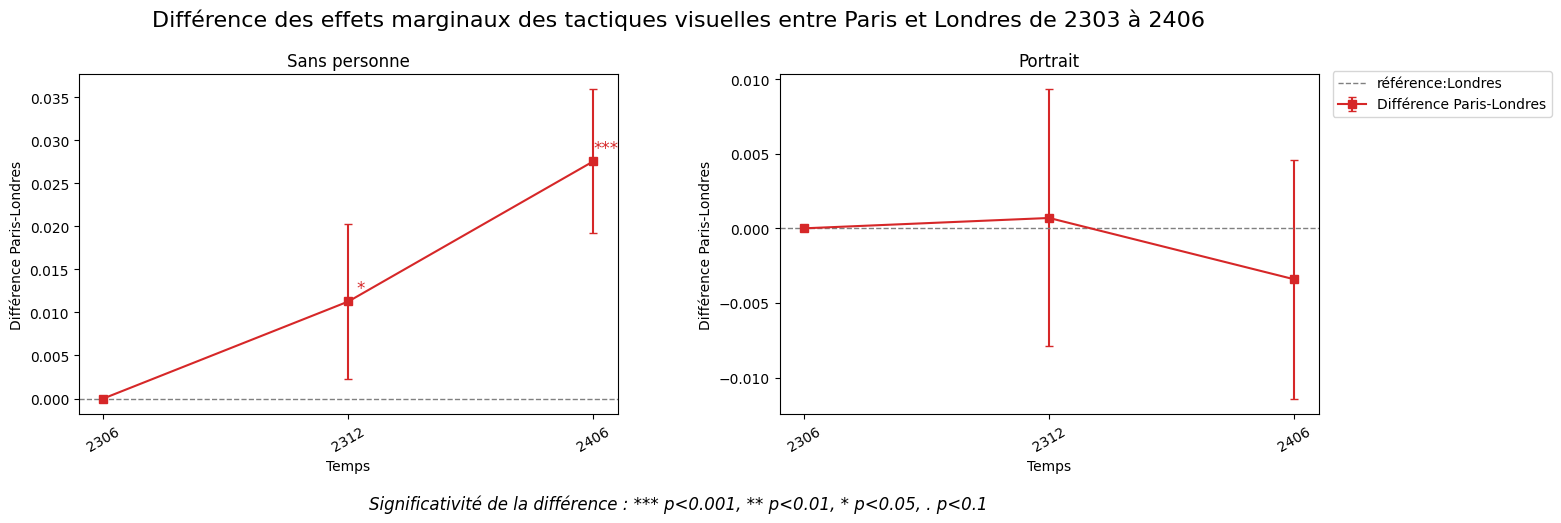

In [ ]:
import matplotlib.gridspec as gridspec
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did_interaction

## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(16, 5)) # sharey=True
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.3)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2])
axes.extend([ax1, ax2])


## plot
tactics_pic=[
 'C(host_picture_type)[T.no_person]',
 'C(host_picture_type)[T.pro_style]'
]
title_pic=['Sans personne', 'Portrait']

title_map=dict(zip(tactics_pic, title_pic))

for i, var in enumerate(tactics_pic):
    # print(i, var)
    plot_one_did_interaction(df_plot=df_plot_did, axes=axes, i=i, var=var, title=title_map.get(var,""))


## ---legend 2facets----
fig.suptitle(
        "Différence des effets marginaux des tactiques visuelles entre Paris et Londres",
        fontsize=16,
        y=1.01
    )

handles, labels =axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(1.05, 0.9)
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la différence : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 0.8, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()
## 增强personne，对portrait无影响
